![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 1. Waveguides

Welcome to our Photonic Integrated Circuits Laboratory! Throughout the course, we will be using a Python package called [GDSFactory](https://gdsfactory.github.io/gdsfactory/index.html). This is an open-source tool, and is a great alternative to other commercial software like Synopsys Optodesigner, Luceda Photonics, or Lumerical/Interconnect. Since it runs on Python, you have two options for executing your laboratory tasks:

1. **Local installation on your own PC** (Recommended): Please note that we will not spend class time on installing the software. However, feel free to reach out if you need help with the installation.

2. **Cloud Workspace**: Alternatively, you can use a cloud-based solution if the Local installation does not work.

## 0. Imports

For this laboratory you will need the following libraries:

In [66]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

nm = 1e-3
wavelength = np.linspace(1500, 1600,11) * nm
f = td.C_0 / wavelength


In [67]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

## LO.1. Effective index of a waveguide

### Convergence Tests
We have asumed until now, that the **real** value of the effective index for each cross-section is the value provided by this mode-solver. However, this number relies on a numerical method, making it sensible to some input parameters, such as the selected grid. The objective of this section is to find the dependence of the **calculated** value of the effective index with the *grid_resolution* and the *max_grid_scaling*, the two parameters that we can modify from the automatic grid function used at the gt.modes.Waveguide() function.  <br>
- Consider a 1.2 um width deep waveguide (SiNx), with 0.3 um height operating at 1550 nm.
    - Sweep the *grid_resolution* between 10 and 100 in steps of 10. Plot the **calculated** effective index vs the *grid_resolution*. 
    - Select a value for the *grid_resolution* from the latter sweep (where the calculated index remains almost constant), and sweep the *max_grid_scaling* from 1.2 to 1.6 in steps of 0.1. Plot the **calculated** effective index vs the *max_grid_scaling*.
    - Conclude which will be the best configuration for the grid parameters for this particular case. 

2026-02-23 15:05:45.688 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_fbe312fd02002ae4.npz.
1.6053726786184481


array([0.99513202, 0.00992386, 0.96394291, 0.04952919])

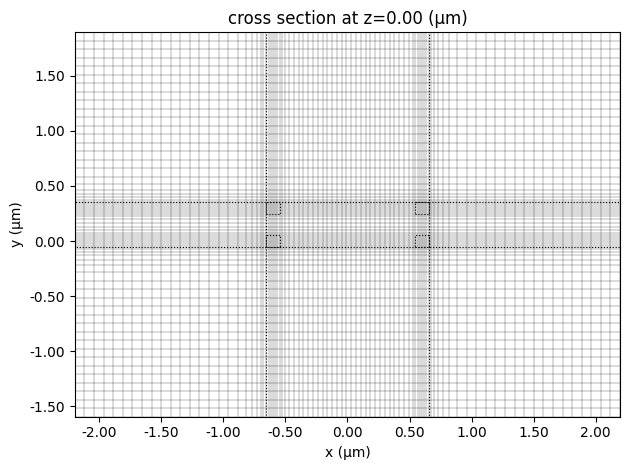

In [3]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=1.2, # Waveguide width
    core_thickness=300 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=4, # Targeted number of modes to find 
    max_grid_scaling=1.3, # Parameters of the grid 
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

#deep_waveguide.plot_index()
deep_waveguide.plot_grid() # para ver el mallado
print(deep_waveguide.n_eff[0].real) # calcular el indice

deep_waveguide.fraction_te

# Student continue your code here ...

In [28]:
n_eff_matrix=[]
grid_res=[]
for i in range(10,110,10):
    deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=1.2, # Waveguide width
    core_thickness=300 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=4, # Targeted number of modes to find 
    max_grid_scaling=1.5, # Parameters of the grid 
    grid_resolution=i, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    )
    n_eff_matrix.append(deep_waveguide.n_eff[0].real)
    grid_res.append(i)

print (n_eff_matrix)

2026-02-16 07:01:45.685 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_13fe960528db7e9b.npz.
2026-02-16 07:01:45.695 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cf92515ae4232c65.npz.
2026-02-16 07:01:45.702 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_152975b7cd7bd92b.npz.
2026-02-16 07:01:45.707 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_721700b7522a7617.npz.
2026-02-16 07:01:45.717 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_0ea6c3bb3b1c00e8.npz.
2026-02-16 07:01:45.724 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_67a04e2475ce3436.npz.
2026-02-16 07:01:45.732 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_b110164ae7f9a70a.npz.
2026-02-16 07:01:45.739 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c8d8b6bf9be8a3e8.npz.


/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/d

07:03:21 -05 WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

2026-02-16 07:03:21.489 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_bf9d22383e930dfa.npz.
[np.float64(1.6292176135816765), np.float64(1.6052479180535963), np.float64(1.614001973470128), np.float64(1.61159935779143), np.float64(1.6053589955147287), np.float64(1.6053793907406797), np.float64(1.6053907755111803), np.float64(1.6052625161349372), np.float64(1.6054075206236817), np.float64(1.6054130304221943)]


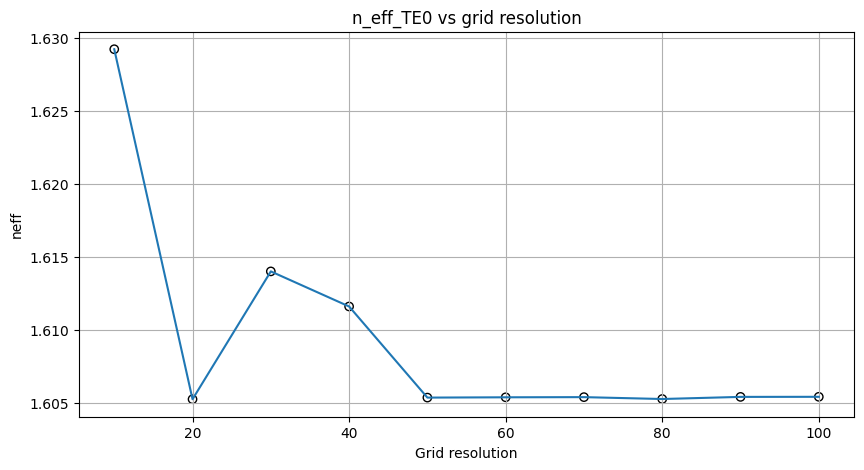

In [29]:

plt.figure(figsize=(10, 5))
plt.scatter(grid_res, n_eff_matrix,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(grid_res, n_eff_matrix)
plt.title(f"n_eff_TE0 vs grid resolution")
plt.xlabel("Grid resolution")
plt.ylabel("neff")
plt.grid()

In [47]:
#Para 50 de grid resolution

n_eff_matrix_sca50=[]
grid_scaling=[]
for i in range(2,7,1):
    deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=1.2, # Waveguide width
    core_thickness=300 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=4, # Targeted number of modes to find 
    max_grid_scaling=1+i/10, # Parameters of the grid 
    grid_resolution=50, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    )
    n_eff_matrix_sca50.append(deep_waveguide.n_eff[0].real)
    grid_scaling.append(1+i/10)

print(n_eff_matrix_sca50)
print(grid_scaling)

2026-02-16 07:21:25.561 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e00efb529108c566.npz.
2026-02-16 07:21:25.570 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_fa75f705ebe9fdb1.npz.
2026-02-16 07:21:25.578 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1f6115e7472c3439.npz.
2026-02-16 07:21:25.584 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_0ea6c3bb3b1c00e8.npz.
2026-02-16 07:21:25.590 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_a7d86abe459c1cd5.npz.
[np.float64(1.6053791442167504), np.float64(1.6053673435378892), np.float64(1.6051416263396405), np.float64(1.6053589955147287), np.float64(1.6055782940151493)]
[1.2, 1.3, 1.4, 1.5, 1.6]


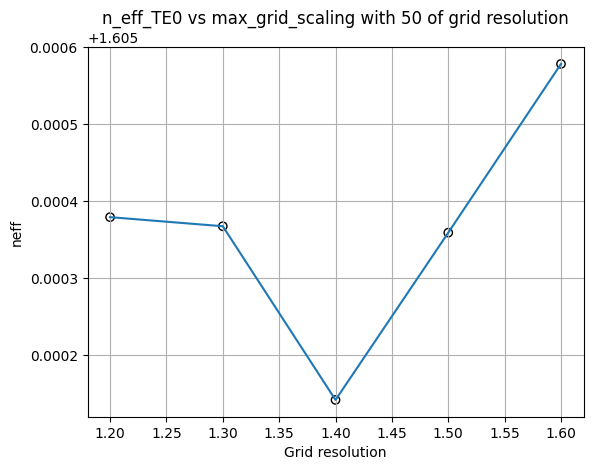

In [49]:


plt.scatter(grid_scaling, n_eff_matrix_sca50,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(grid_scaling, n_eff_matrix_sca50)
plt.title(f"n_eff_TE0 vs max_grid_scaling with 50 of grid resolution")
plt.xlabel("Grid resolution")
plt.ylabel("neff")
plt.grid()

In [50]:
#Para 60 de grid resolution

n_eff_matrix_sca60=[]
grid_scaling=[]
for i in range(2,7,1):
    deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=1.2, # Waveguide width
    core_thickness=300 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=4, # Targeted number of modes to find 
    max_grid_scaling=1+i/10, # Parameters of the grid 
    grid_resolution=60, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    )
    n_eff_matrix_sca60.append(deep_waveguide.n_eff[0].real)
    grid_scaling.append(1+i/10)

print(n_eff_matrix_sca60)
print(grid_scaling)

2026-02-16 07:21:41.593 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_db01c3f1888a3ea0.npz.
2026-02-16 07:21:41.602 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_acdca616f9b375ed.npz.
2026-02-16 07:21:41.609 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1b23799e826f5880.npz.
2026-02-16 07:21:41.615 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_67a04e2475ce3436.npz.
2026-02-16 07:21:41.623 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_a8160814b6407326.npz.
[np.float64(1.6053916518765718), np.float64(1.6055675594649352), np.float64(1.605380187303021), np.float64(1.6053793907406797), np.float64(1.6053776245905769)]
[1.2, 1.3, 1.4, 1.5, 1.6]


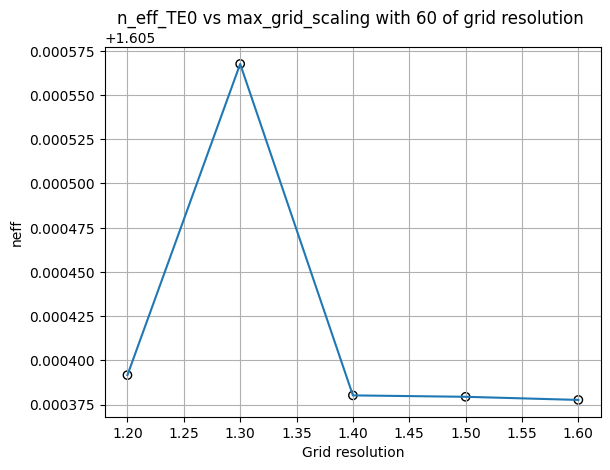

In [51]:


plt.scatter(grid_scaling, n_eff_matrix_sca60,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(grid_scaling, n_eff_matrix_sca60)
plt.title(f"n_eff_TE0 vs max_grid_scaling with 60 of grid resolution ")
plt.xlabel("Grid resolution")
plt.ylabel("neff")
plt.grid()

In [52]:
#Para 20 de grid resolution

n_eff_matrix_sca20=[]
grid_scaling=[]
for i in range(2,7,1):
    deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=1.2, # Waveguide width
    core_thickness=300 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=4, # Targeted number of modes to find 
    max_grid_scaling=1+i/10, # Parameters of the grid 
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    )
    n_eff_matrix_sca20.append(deep_waveguide.n_eff[0].real)
    grid_scaling.append(1+i/10)

print(n_eff_matrix_sca20)
print(grid_scaling)

2026-02-16 07:21:47.918 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_29761b037c0c9026.npz.
2026-02-16 07:21:47.927 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_fbe312fd02002ae4.npz.
2026-02-16 07:21:47.935 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_76e2764f504071ba.npz.
2026-02-16 07:21:47.942 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cf92515ae4232c65.npz.
2026-02-16 07:21:47.951 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_683206c3f01233c4.npz.
[np.float64(1.6049334055265747), np.float64(1.6053726786184481), np.float64(1.6047306030440103), np.float64(1.6052479180535963), np.float64(1.605236201827348)]
[1.2, 1.3, 1.4, 1.5, 1.6]


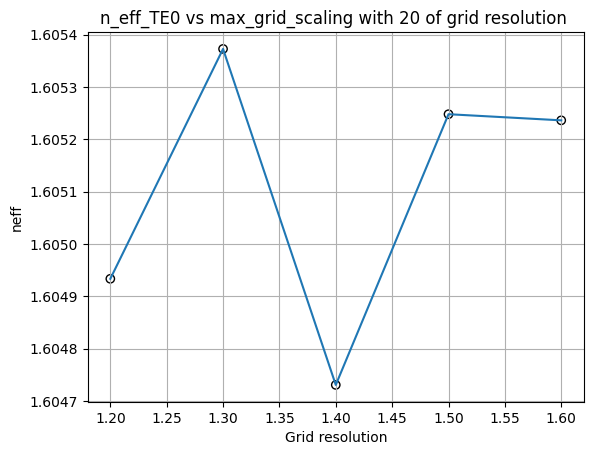

In [53]:


plt.scatter(grid_scaling, n_eff_matrix_sca20,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(grid_scaling, n_eff_matrix_sca20)
plt.title(f"n_eff_TE0 vs max_grid_scaling with 20 of grid resolution ")
plt.xlabel("Grid resolution")
plt.ylabel("neff")
plt.grid()

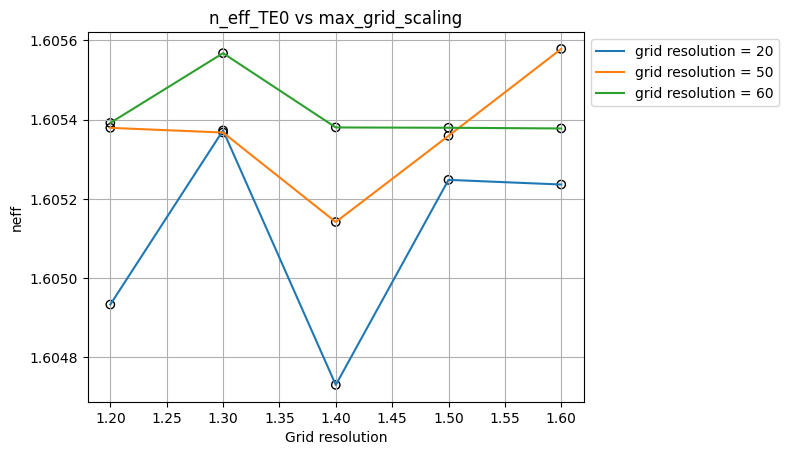

In [63]:
plt.scatter(grid_scaling, n_eff_matrix_sca20,edgecolors='k',facecolors='none')
plt.plot(grid_scaling, n_eff_matrix_sca20,label = 'grid resolution = 20')
plt.scatter(grid_scaling, n_eff_matrix_sca50,edgecolors='k',facecolors='none')
plt.plot(grid_scaling,n_eff_matrix_sca50,label = 'grid resolution = 50')
plt.scatter(grid_scaling, n_eff_matrix_sca60,edgecolors='k',facecolors='none')
plt.plot(grid_scaling,n_eff_matrix_sca60,label = 'grid resolution = 60')
plt.title(f"n_eff_TE0 vs max_grid_scaling")
plt.xlabel("Grid resolution")
plt.ylabel("neff")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()

## LO.2. Width dependence

- Perform a sweep of the **deep** waveguide width. Use the code provided in the following cell or program your own sweep. 

  0%|          | 0/11 [00:00<?, ?it/s]

/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/d

09:15:07 -05 WARNING: Mode field at frequency index 0, mode index 2 does not    
             decay at the plane boundaries.                                     

09:15:08 -05 WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

2026-02-16 09:15:08.119 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_d4e08a79f5fdb243.npz.


...

2026-02-16 09:15:24.079 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_ba98d942d1777789.npz.


/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/d

2026-02-16 09:15:26.653 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_e2f3b827e4df080d.npz.


  0%|          | 0/11 [00:00<?, ?it/s]

2026-02-16 09:15:26.688 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_d4e08a79f5fdb243.npz.
2026-02-16 09:15:26.700 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_886c9661f4e132ea.npz.
2026-02-16 09:15:26.706 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_fb049743d89bf4e7.npz.
2026-02-16 09:15:26.713 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_a02fd81c9517ebcb.npz.
2026-02-16 09:15:26.721 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_dec9166d8db3db87.npz.
2026-02-16 09:15:26.730 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_73cf54d009fd1f31.npz.
2026-02-16 09:15:26.742 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_fbe312fd02002ae4.npz.
2026-02-16 09:15:26.750 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_b63989cfe5282118.npz.


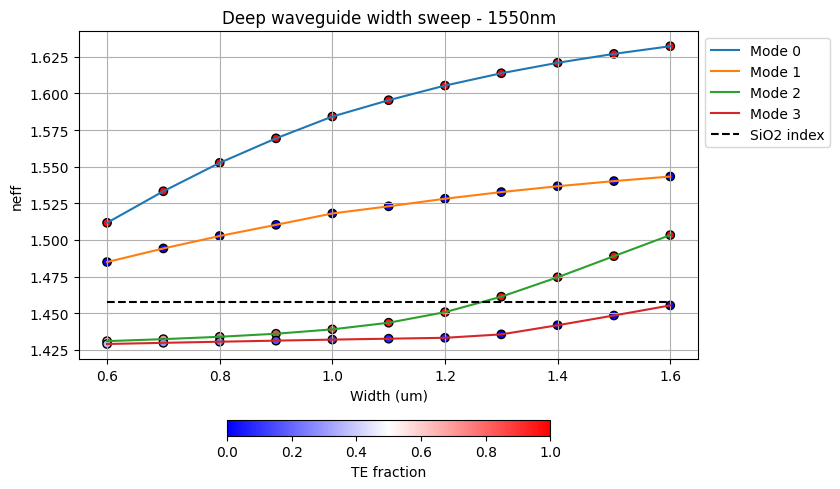

In [7]:


wavelength = 1.55 # Student code here

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=1.2,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    slab_thickness=0 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.3,
    grid_resolution=20, 
)


w = [] # Student code here Aqui debe ser un vector

for i in range (6,17,1):
    w.append(i/10)

sweep_neff = gt.modes.sweep_n_eff(deep_waveguide, 
                             core_width=w)

sweep_tefraction = gt.modes.sweep_fraction_te(deep_waveguide,
                                              core_width=w)

plt.figure(figsize=(10, 5))
for k in range(sweep_neff.shape[1]):
    plt.scatter(w, sweep_neff[:,k].real,edgecolors='k',c=sweep_tefraction.sel(mode_index=k),vmin=0, vmax=1,label = '__nolegend__',cmap='bwr')
    plt.plot(w, sweep_neff[:,k].real,label=f'Mode {k}')
    print(k)
    print(w)
    print(sweep_neff[:,k].real)
    

plt.title("Deep waveguide width sweep - 1550nm")
plt.xlabel("Width (um)")
plt.ylabel("neff")
plt.grid()
plt.hlines(np.mean(box_index), xmin=np.min(w), xmax=np.max(w), colors='k', linestyles='dashed',label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.colorbar(orientation='horizontal',fraction=0.04).set_label("TE fraction")


#rojo TE y azul TM

## LO.3. Waveguide compact model

A compact model of an integrated photonic waveguide is a reduced-order mathematical model that describes the waveguide’s optical behavior—such as phase propagation, loss, and dispersion, using analytical or semi-analytical equations. Consider: 

Transfer function for propagation in a waveguide:

$$
H(\lambda)
= e^{-j\,\beta(\lambda)\,z}
= e^{-j\,\mathrm{Re}\{\beta(\lambda)\}\,z}\,
  e^{\mathrm{Im}\{\beta(\lambda)\}\,z}.
$$

Where 

$$
\beta(\lambda)
= \frac{2\pi}{\lambda}\,\mathrm{Re}\{n_\mathrm{eff}(\lambda)\}.
$$

Let's model the waveguide's effective index wavelength variation using a second order polynomial:

$$
n_\mathrm{eff}(\lambda)
= n_{1} + n_{2}\,(\lambda-\lambda_{0}) + n_{3}\,(\lambda-\lambda_{0})^{2}
$$

Where 

1. 
$$
n_\mathrm{eff}(\lambda_0) = n_1
$$
2. 
$$
n_g(\lambda_0) = n_1 - n_2\,\lambda_0
$$
3. 
$$
D = -\frac{2\,\lambda_0\,n_3}{c}\;\;[\mathrm{s}^2/\mathrm{m}]
$$

- Find the **compact models** of the following waveguides: 
    - Deep waveguide, height = 300nm, width = 1.2um 
    - Shallow waveguide, core height = 300nm, slab height = 150 nm, width = 1.2um 

**TIP**. Use the Lab0.1.Modesolver results (neff vs lambda) as starting point. Fit the results using a second order polynomial (with the lambda_0 shift) and relate the fit results to n_g and D values.

2026-02-23 16:26:28.780 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cfb6f00926e7682c.npz.


[0.99497504 0.00955424 0.96332419 0.05006507]
[-0.05       -0.04795918 -0.04591837 -0.04387755 -0.04183673 -0.03979592
 -0.0377551  -0.03571429 -0.03367347 -0.03163265 -0.02959184 -0.02755102
 -0.0255102  -0.02346939 -0.02142857 -0.01938776 -0.01734694 -0.01530612
 -0.01326531 -0.01122449 -0.00918367 -0.00714286 -0.00510204 -0.00306122
 -0.00102041  0.00102041  0.00306122  0.00510204  0.00714286  0.00918367
  0.01122449  0.01326531  0.01530612  0.01734694  0.01938776  0.02142857
  0.02346939  0.0255102   0.02755102  0.02959184  0.03163265  0.03367347
  0.03571429  0.0377551   0.03979592  0.04183673  0.04387755  0.04591837
  0.04795918  0.05      ]
[1.61596895 1.61550829 1.61504844 1.6145894  1.61413117 1.61367376
 1.61321716 1.61276137 1.6123064  1.61185224 1.61139889 1.61094635
 1.61049463 1.61004372 1.60959362 1.60914434 1.60869586 1.6082482
 1.60780135 1.60735532 1.60691009 1.60646568 1.60602208 1.60557929
 1.60513731 1.60469614 1.60425578 1.60381624 1.6033775  1.60293958
 1.6025024

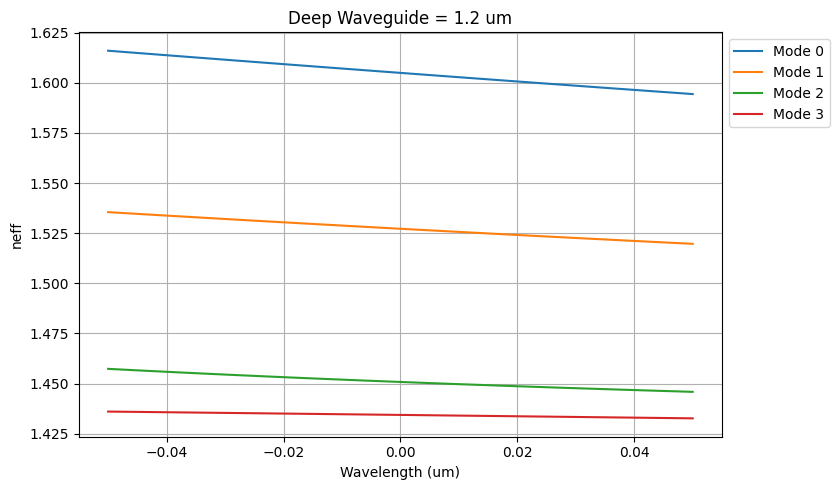

In [30]:
# STUDENT! Put your code here.




wavelengthIni=1.5
wavelengthFin=1.6
step=0.2


rangeW=wavelengthFin-wavelengthIni
numStep=rangeW/step

wavelength = np.linspace(wavelengthIni, wavelengthFin) 

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength, 
    core_width=1.2, 
    slab_thickness=0*nm,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

res_neff = deep_waveguide.n_eff # In this case, the result is not just a number, is a wavelength-dependent vector
res_te = deep_waveguide.fraction_te # Wavelength-dependent vector
res_tm =deep_waveguide.fraction_tm # Wavelength-dependent vector
print(deep_waveguide.fraction_te)

plt.figure(figsize=(10, 5))
for k in range(res_neff.shape[1]):
    # It's necessary to 'access' each element on the array
    #plt.scatter(wavelength-1.55, res_neff[:,k].real,edgecolors='k',facecolors='none',label = '__nolegend__')
    plt.plot(wavelength-1.55, res_neff[:,k].real,label=f'Mode {k}')
    print(wavelength-1.55)
    print(res_neff[:,k].real)
plt.title(f"Deep Waveguide = {1.2} um")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
#print(box_index[5])
#matriz = np.array([[1, 1, 1, 1, 1]])
#plt.plot(wavelength, 1.4577374304687887*matriz,'k--', label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])



In [31]:
#modo 0 es TE y modo 1 es TM 

#Para TE0:
c=3*10^8 # m/s
[n3_E0,n2_E0,n1_E0]=np.polyfit(wavelength-1.55, res_neff[:,0].real, 2)

n_eff_E0=n1_E0
n_g_E0=n1_E0-n2_E0*1550*nm
D_E0=-(2*1550*nm*n3_E0)/c

print(f"n_eff_E0 = {n_eff_E0}")
print(f"n_g_E0 = {n_g_E0}")
print(f"D = {D_E0}")

n_eff_E0 = 1.6049166277742604
n_g_E0 = 1.939989993835972
D = -0.013718574432109299


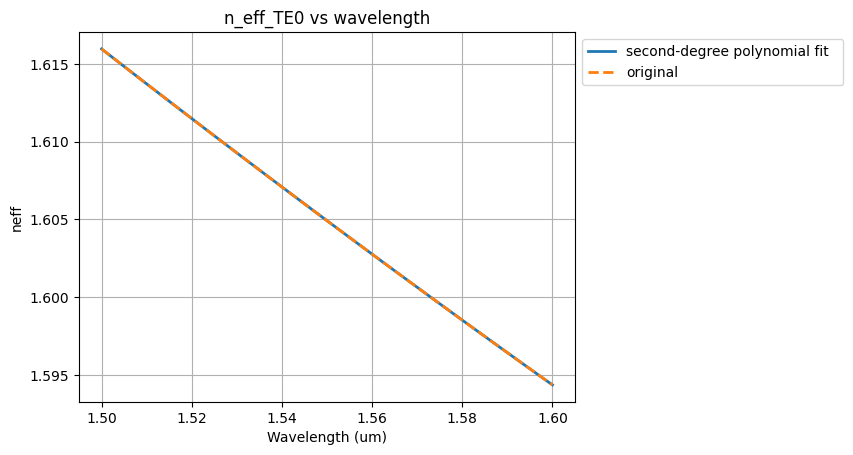

In [32]:

n_eff_func_E0=[]
for i in range(0,len(wavelength),1):
    lamd_wa=wavelength[i]-1.55
    n_eff_func_E0.append(n1_E0+n2_E0*lamd_wa+n3_E0*(lamd_wa**2))
    #print(wavelength[i])


#plt.scatter(wavelength, n_eff_func_E0,edgecolors='k',facecolors='none')
plt.plot(wavelength, n_eff_func_E0,label = 'second-degree polynomial fit  ', linewidth=2)
#plt.scatter(wavelength, res_neff[:,0].real,edgecolors='k',facecolors='none')
plt.plot(wavelength, res_neff[:,0].real,linestyle='--',linewidth=2,label = 'original')
plt.title(f"n_eff_TE0 vs wavelength")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()


In [33]:
#Para TM0 que es el modo 1:
c=3*10^8 # m/s
[n3_M0,n2_M0,n1_M0]=np.polyfit(wavelength-1.55, res_neff[:,1].real, 2)

n_eff_M0=n1_M0
n_g_M0=n1_M0-n2_M0*1550*nm
D_M0=-(2*1550*nm*n3_M0)/c

print(f"n_eff_M0 = {n_eff_M0}")
print(f"n_g_M0 = {n_g_M0}")
print(f"D_M0 = {D_M0}")

n_eff_M0 = 1.527189234093962
n_g_M0 = 1.772001692289885
D_M0 = -0.021676350629097927


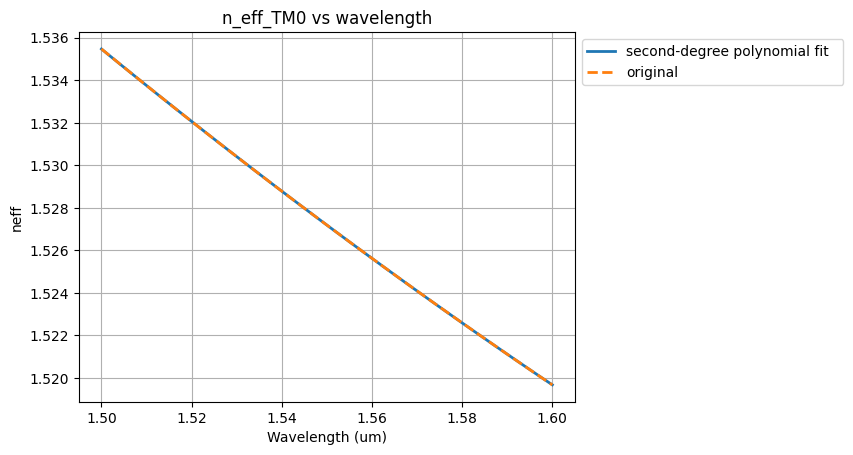

In [34]:

n_eff_func_M0=[]
for i in range(0,len(wavelength),1):
    lamd_wa=wavelength[i]-1.55
    n_eff_func_M0.append(n1_M0+n2_M0*lamd_wa+n3_M0*(lamd_wa**2))
    #print(wavelength[i])

#plt.scatter(wavelength, n_eff_func_M0,edgecolors='k',facecolors='none')
plt.plot(wavelength, n_eff_func_M0,label = 'second-degree polynomial fit  ', linewidth=2)
#plt.scatter(wavelength, res_neff[:,1].real,edgecolors='k',facecolors='none')
plt.plot(wavelength, res_neff[:,1].real,linestyle='--',linewidth=2,label = 'original')
plt.title(f"n_eff_TM0 vs wavelength")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()


diferencia entre el primer y ultimo valor: 0.021617886316268375
diferencia entre el primer y ultimo valor TM: 0.015800881390828136


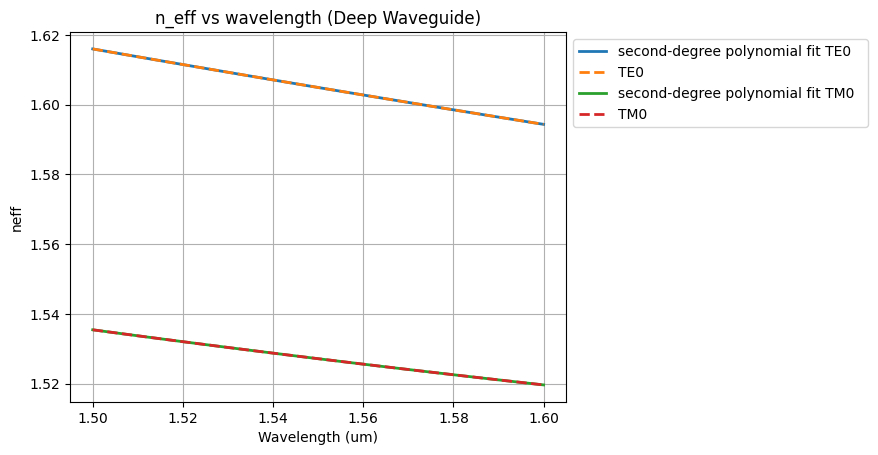

In [35]:
plt.plot(wavelength, n_eff_func_E0,label = 'second-degree polynomial fit TE0 ', linewidth=2)
plt.plot(wavelength, res_neff[:,0].real,linestyle='--',linewidth=2,label = 'TE0')
print(f"diferencia entre el primer y ultimo valor: {res_neff[0,0].real-res_neff[len(res_neff)-1,0].real}")
plt.plot(wavelength, n_eff_func_M0,label = 'second-degree polynomial fit TM0  ', linewidth=2)
plt.plot(wavelength, res_neff[:,1].real,linestyle='--',linewidth=2,label = 'TM0')
print(f"diferencia entre el primer y ultimo valor TM: {res_neff[0,1].real-res_neff[len(res_neff)-1,1].real}")
plt.title(f"n_eff vs wavelength (Deep Waveguide)")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()

/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/d

06:15:25 -05 WARNING: Mode field at frequency index 0, mode index 1 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 1, mode index 1 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 1, mode index 3 does not    
             decay at the plane boundaries.                                     

...

             WARNING: Mode field at frequency index 3, mode index 1 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 3, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 4, mode index 1 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 4, mode index 3 does not    
             decay at the plane boundaries.                                     

2026-03-01 06:15:27.005 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_2e8a8333e2310d26.npz.
[0.99696875 0.70437803 0.17711616 0.99999234]


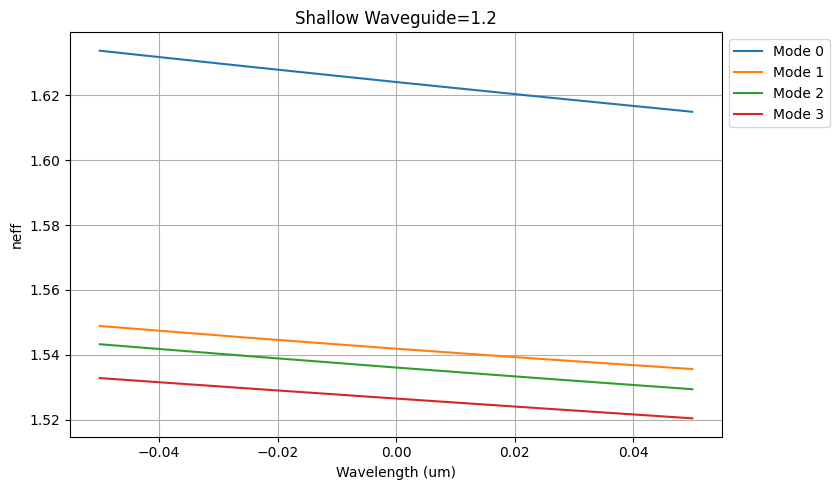

In [6]:
# ahora para la guia shallow:
wavelengthIni=1.5
wavelengthFin=1.6
step=0.02


rangeW=wavelengthFin-wavelengthIni
numStep=rangeW/step

wavelength = np.linspace(wavelengthIni, wavelengthFin,int(numStep)) 

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength, 
    core_width=1.2, 
    slab_thickness=150*nm,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

res_neff = deep_waveguide.n_eff # In this case, the result is not just a number, is a wavelength-dependent vector
res_te = deep_waveguide.fraction_te # Wavelength-dependent vector
res_tm =deep_waveguide.fraction_tm # Wavelength-dependent vector
print(deep_waveguide.fraction_te)

plt.figure(figsize=(10, 5))
for k in range(res_neff.shape[1]):
    # It's necessary to 'access' each element on the array
    #plt.scatter(wavelength-1.55, res_neff[:,k].real,edgecolors='k',facecolors='none',label = '__nolegend__')
    plt.plot(wavelength-1.55, res_neff[:,k].real,label=f'Mode {k}')
   
plt.title(f"Shallow Waveguide={1.2}")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
#print(box_index[5])
#matriz = np.array([[1, 1, 1, 1, 1]])
#plt.plot(wavelength, 1.4577374304687887*matriz,'k--', label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])



In [37]:
#modo 0 es TE y modo 1 es TM 

#Para TE0:
c=3*10^8 # m/s
[n3_E0,n2_E0,n1_E0]=np.polyfit(wavelength-1.55, res_neff[:,0].real, 2)

n_eff_E0=n1_E0
n_g_E0=n1_E0-n2_E0*1550*nm
D_E0=-(2*1550*nm*n3_E0)/c

print(f"n_eff_E0 = {n_eff_E0}")
print(f"n_g_E0 = {n_g_E0}")
print(f"D = {D_E0}")

n_eff_func_E0=[]
for i in range(0,len(wavelength),1):
    lamd_wa=wavelength[i]-1.55
    n_eff_func_E0.append(n1_E0+n2_E0*lamd_wa+n3_E0*(lamd_wa**2))


#Para TM0 que es el modo 1:
c=3*10^8 # m/s
[n3_M0,n2_M0,n1_M0]=np.polyfit(wavelength-1.55, res_neff[:,2].real, 2)

n_eff_M0=n1_M0
n_g_M0=n1_M0-n2_M0*1550*nm
D_M0=-(2*1550*nm*n3_M0)/c

print(f"n_eff_M0 = {n_eff_M0}")
print(f"n_g_M0 = {n_g_M0}")
print(f"D_M0 = {D_M0}")

n_eff_func_M0=[]
for i in range(0,len(wavelength),1):
    lamd_wa=wavelength[i]-1.55
    n_eff_func_M0.append(n1_M0+n2_M0*lamd_wa+n3_M0*(lamd_wa**2))

n_eff_E0 = 1.6240906291675177
n_g_E0 = 1.915756966186721
D = -0.01348456575999983
n_eff_M0 = 1.536101777025915
n_g_M0 = 1.7510333111295564
D_M0 = -0.013800737887581


diferencia entre el primer y ultimo valor: 0.018818492706203394
diferencia entre el primer y ultimo valor TM: 0.013277433309259346


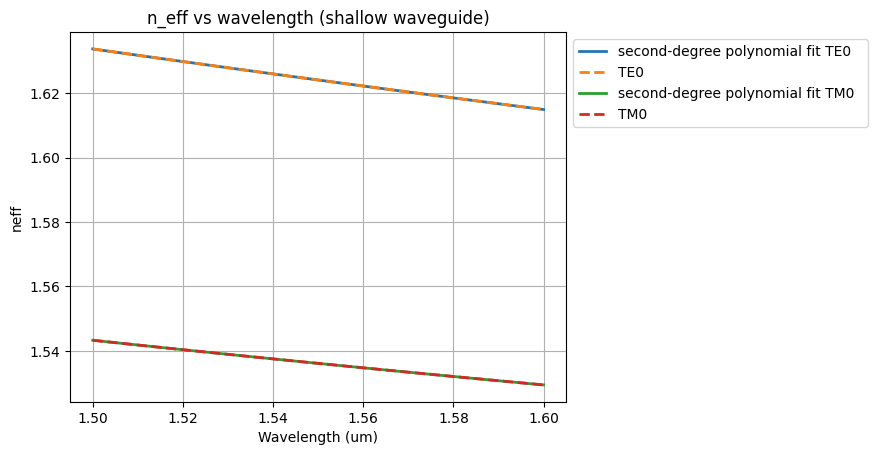

In [38]:
plt.plot(wavelength, n_eff_func_E0,label = 'second-degree polynomial fit TE0 ', linewidth=2)
plt.plot(wavelength, res_neff[:,0].real,linestyle='--',linewidth=2,label = 'TE0')
print(f"diferencia entre el primer y ultimo valor: {res_neff[0,0].real-res_neff[len(res_neff)-1,0].real}")
plt.plot(wavelength, n_eff_func_M0,label = 'second-degree polynomial fit TM0  ', linewidth=2)
plt.plot(wavelength, res_neff[:,2].real,linestyle='--',linewidth=2,label = 'TM0')
print(f"diferencia entre el primer y ultimo valor TM: {res_neff[0,1].real-res_neff[len(res_neff)-1,1].real}")
plt.title(f"n_eff vs wavelength (shallow waveguide)")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()

## LO.4. Bend waveguide radius vs. loss – deep

The bend loss has three primary contributions:

1. Mode-mismatch loss
2. Radiation loss
3. Propagation loss

2026-03-01 06:48:57.762 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_35cb48b3d856a579.npz.


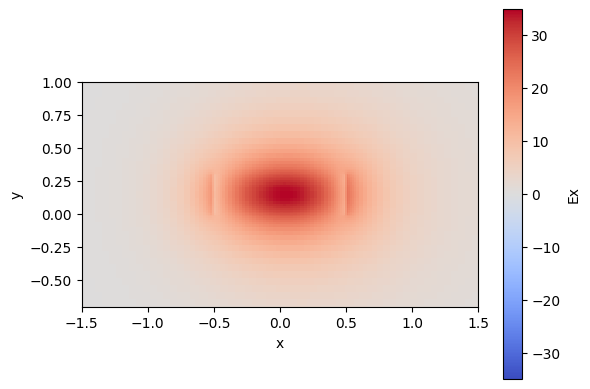

In [24]:
bend_1550 = gt.modes.Waveguide(
    wavelength=1550 * nm,
    core_width=1,
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30, 
    bend_radius=25, # Bend radius (um)
)


bend_1550.plot_field(field_name="Ex", 
                     mode_index=0, # Field to be plotted
                     value='real', # Real - abs - imag
                     cmap='coolwarm',
                     xlim=(-1.5, 1.5), # Set the x and y limits
                     ylim=(-0.7, 1)) 

### Mode-mismatch loss

Bend waveguide mode differs slightly from the straight waveguide mode, wich yield into mode-convertion losses. We can calculate this factor with as the overlap of the latter two modes. 

This is already implemented on GDSfactory library: 

  0%|          | 0/21 [00:00<?, ?it/s]

/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/d

[0.9724289  0.98374288 0.98882887 0.99174023 0.99358699 0.99483591
 0.99572057 0.99636997 0.99686043 0.99723971 0.99753886 0.99777876
 0.99797396 0.99813482 0.99826886 0.99838163 0.99847737 0.9985593
 0.99862988 0.99869109 0.99874449]


Text(0, 0.5, 'Mismatch (dB)')

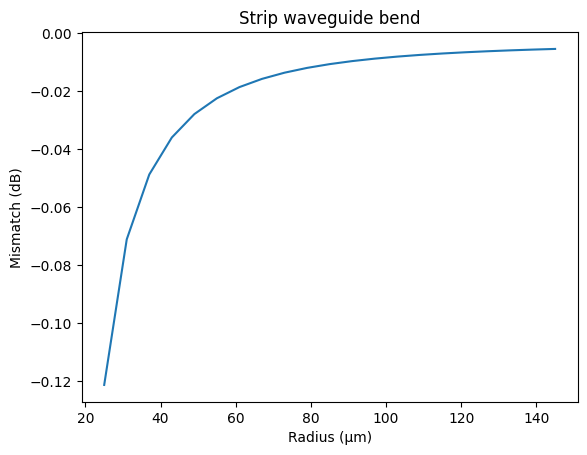

In [63]:
bend_1550 = gt.modes.Waveguide(
    wavelength=1550 * nm,
    core_width=1,
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30, 
    bend_radius=25, # Bend radius
)


radii = np.arange(25, 150,6)

mismatch = gt.modes.sweep_bend_mismatch(bend_1550, radii)
print(mismatch)

plt.plot(radii, 10 * np.log10(mismatch))
plt.title("Strip waveguide bend")
plt.xlabel("Radius (μm)")
plt.ylabel("Mismatch (dB)")

### Propagation loss

Consider the equivalent linear length of the quarter-circle bend. Light will attenuate following a trend quantified with the experimentally measured parameter $$\alpha [\mathrm{dB}/\mathrm{cm}]$$. It depends on the fabrication process mainly. We will add this loss (in dBs) to the mode-mismatch loss to calculate the total loss per bend. 

*We are not considering the radiation losses, mainly because is not easy to implement a quick simulation for this parameter. Under certain conditions, the main loss sources are the ones considered in this example


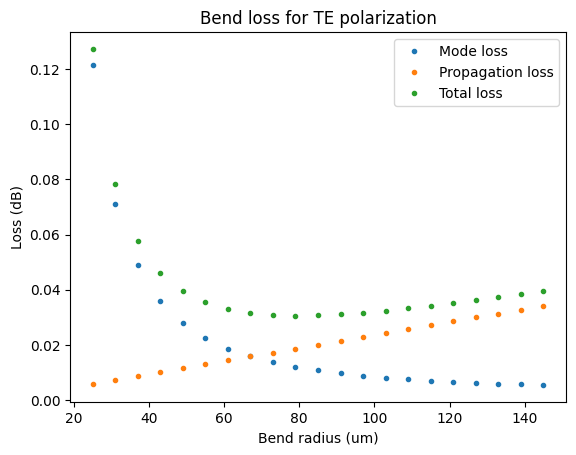

In [64]:
dB_cm = 1.5  # dB/cm Technology loss - 
length = 0.5 * np.pi * radii * 1e-6
propagation_loss = dB_cm * length * 1e2
propagation_loss

plt.title("Bend loss for TE polarization")
plt.plot(radii, -10 * np.log10(mismatch), ".", label="Mode loss")
plt.plot(radii, propagation_loss, ".", label="Propagation loss")
plt.plot(radii, propagation_loss-10 * np.log10(mismatch), ".", label="Total loss")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB)")
plt.legend()

2026-03-01 07:41:01.696 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ba9a5391752fe20f.npz.
2026-03-01 07:41:01.704 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_0490c19e249eef00.npz.


/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/d

07:41:07 -05 WARNING: Mode field at frequency index 0, mode index 2 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

2026-03-01 07:41:07.537 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_89232f97c103d672.npz.


...

2026-03-01 07:41:57.852 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_de4c9e33f75b60b6.npz.


/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/d

07:42:02 -05 WARNING: Mode field at frequency index 0, mode index 2 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

2026-03-01 07:42:02.903 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_c49e478cc12e08ed.npz.
2026-03-01 07:42:02.922 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_0ad9187382c5e621.npz.


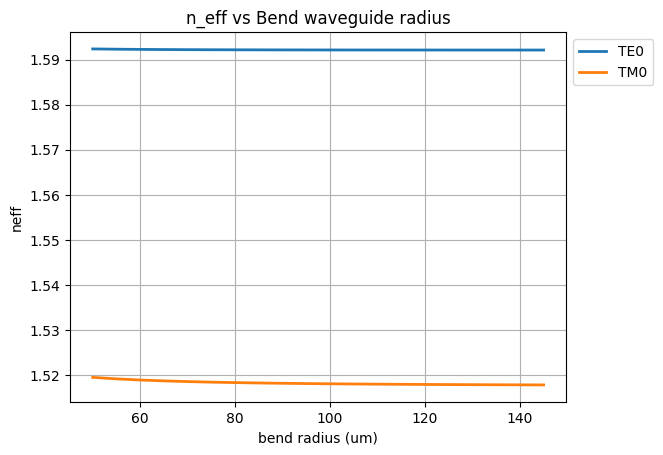

In [52]:
n_eff_Bend_E0=[]
n_eff_Bend_M0=[]
neffs = []

radii = np.arange(50, 150,5)
for r in radii:
    bend_1550 = gt.modes.Waveguide(
         wavelength=1550*nm,
        core_width=1,
        slab_thickness=0.0,
        core_material='sin',
        clad_material='sio2',
        core_thickness=300*nm,
        num_modes=4,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.2,
        grid_resolution=30, 
        bend_radius=r, # Bend radius (um)
    )
    neffs.append(bend_1550.n_eff[0])
    # índices efectivos

    n_eff_Bend_E0.append(bend_1550.n_eff[0].real)
    n_eff_Bend_M0.append(bend_1550.n_eff[1].real)


plt.plot(radii, n_eff_Bend_E0,label = 'TE0 ', linewidth=2)
plt.plot(radii, n_eff_Bend_M0,linewidth=2,label = 'TM0')
plt.title(f"n_eff vs Bend waveguide radius")
plt.xlabel("bend radius (um)")
plt.ylabel("neff")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()
    

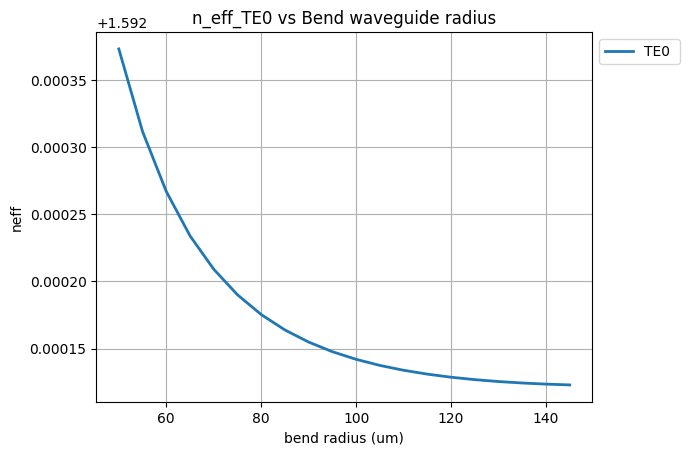

In [53]:
plt.plot(radii, n_eff_Bend_E0,label = 'TE0 ', linewidth=2)
plt.title(f"n_eff_TE0 vs Bend waveguide radius")
plt.xlabel("bend radius (um)")
plt.ylabel("neff")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()

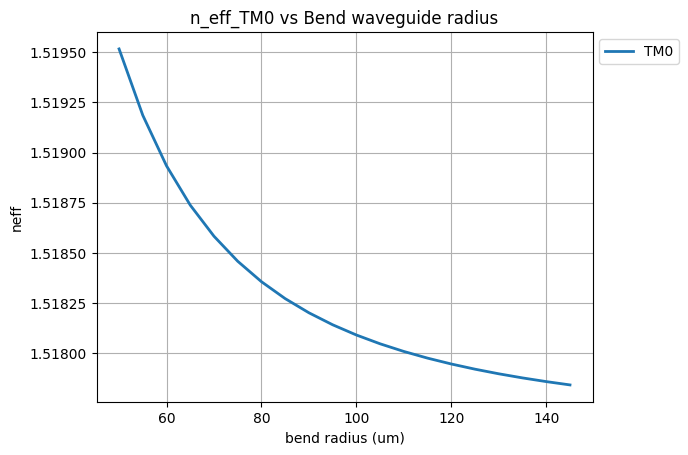

In [54]:

plt.plot(radii, n_eff_Bend_M0,linewidth=2,label = 'TM0')
plt.title(f"n_eff_TM0 vs Bend waveguide radius")
plt.xlabel("bend radius (um)")
plt.ylabel("neff")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()

In [56]:
radii = np.arange(50, 150,5)
bend_1550 = gt.modes.Waveguide(
         wavelength=1550*nm,
        core_width=1,
        slab_thickness=0.0,
        core_material='sin',
        clad_material='sio2',
        core_thickness=300*nm,
        num_modes=2,
        cache_path='.cache/',
        precision='double',
        max_grid_scaling=1.2,
        grid_resolution=30, 
        bend_radius=r, # Bend radius (um)
)

mismatch = gt.modes.sweep_bend_mismatch(bend_1550, radii)
print(mismatch)

  0%|          | 0/20 [00:00<?, ?it/s]

/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/d

[[0.99382843 0.94737125]
 [0.99483591 0.95652171]
 [0.99559212 0.96315206]
 [0.9961742  0.96809808]
 [0.9966316  0.97188317]
 [0.99699744 0.9748448 ]
 [0.99729448 0.97720702]
 [0.99753886 0.97912272]
 [0.99774219 0.98069894]
 [0.99791314 0.98201242]
 [0.99805816 0.98311923]
 [0.99818217 0.98406116]
 [0.998289   0.98486989]
 [0.99838163 0.98556976]
 [0.99846246 0.98617979]
 [0.99853336 0.98671492]
 [0.99859587 0.98718712]
 [0.99865124 0.98760606]
 [0.9987005  0.98797956]
 [0.99874449 0.98831406]]


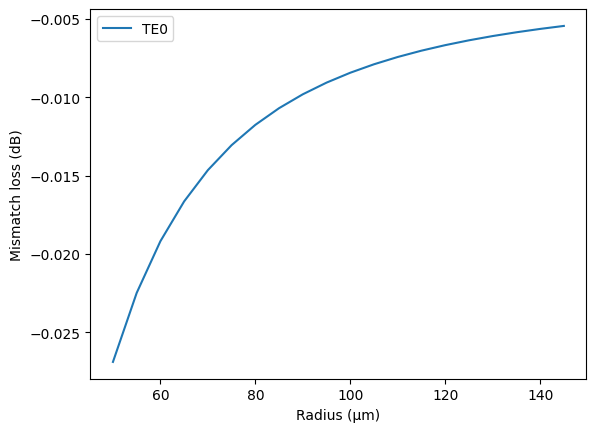

In [57]:
loss_TE = 10*np.log10(mismatch[:,0])
loss_TM = 10*np.log10(mismatch[:,1])

plt.plot(radii, loss_TE, label="TE0")
plt.xlabel("Radius (μm)")
plt.ylabel("Mismatch loss (dB)")
plt.legend()

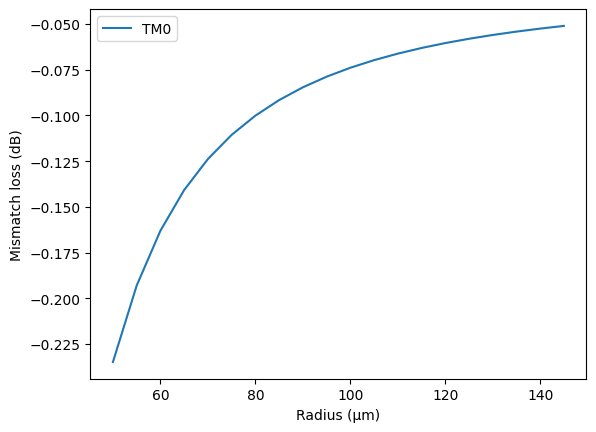

In [58]:


plt.plot(radii, loss_TM, label="TM0")
plt.xlabel("Radius (μm)")
plt.ylabel("Mismatch loss (dB)")
plt.legend()

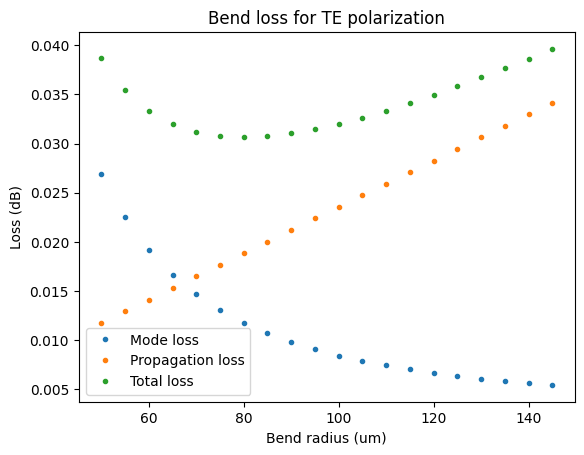

In [59]:
dB_cm = 1.5  # dB/cm Technology loss - 
length = 0.5 * np.pi * radii * 1e-6
propagation_loss = dB_cm * length * 1e2
propagation_loss

plt.title("Bend loss for TE polarization")
plt.plot(radii, -10 * np.log10(mismatch[:,0]), ".", label="Mode loss")
plt.plot(radii, propagation_loss, ".", label="Propagation loss")
plt.plot(radii, propagation_loss-10 * np.log10(mismatch[:,0]), ".", label="Total loss")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB)")
plt.legend()

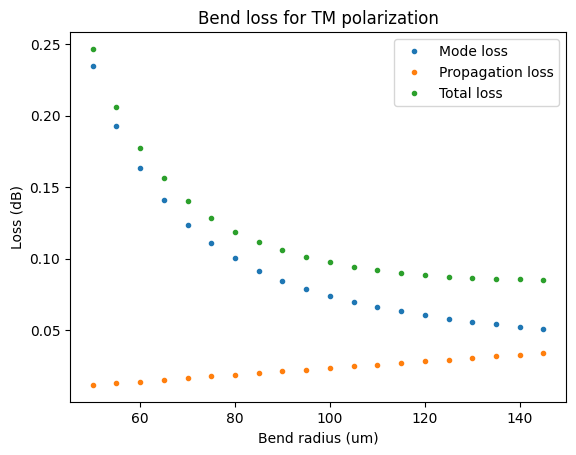

In [60]:
plt.title("Bend loss for TM polarization")
plt.plot(radii, -10 * np.log10(mismatch[:,1]), ".", label="Mode loss")
plt.plot(radii, propagation_loss, ".", label="Propagation loss")
plt.plot(radii, propagation_loss-10 * np.log10(mismatch[:,1]), ".", label="Total loss")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB)")
plt.legend()

- Use the code provided in this section to calculate the safe radius for 1.2 um width deep waveguides at 1.5 um. 

  0%|          | 0/21 [00:00<?, ?it/s]

/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/d

[0.96991194 0.98076333 0.98654281 0.99001764 0.99227275 0.99381954
 0.99492662 0.99574606 0.99636921 0.99685415 0.99723886 0.99754899
 0.99780257 0.99801259 0.99818846 0.99833704 0.99846378 0.99857275
 0.99866703 0.99874912 0.99882109]


Text(0, 0.5, 'Mismatch (dB)')

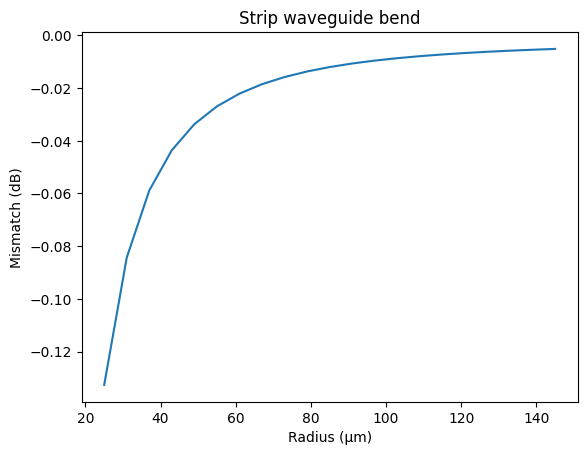

In [61]:
bend_1550 = gt.modes.Waveguide(
    wavelength=1500 * nm,
    core_width=1.2,
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30, 
    bend_radius=25, # Bend radius
)


radii = np.arange(25, 150,6)

mismatch = gt.modes.sweep_bend_mismatch(bend_1550, radii)
print(mismatch)

plt.plot(radii, 10 * np.log10(mismatch))
plt.title("Strip waveguide bend")
plt.xlabel("Radius (μm)")
plt.ylabel("Mismatch (dB)")



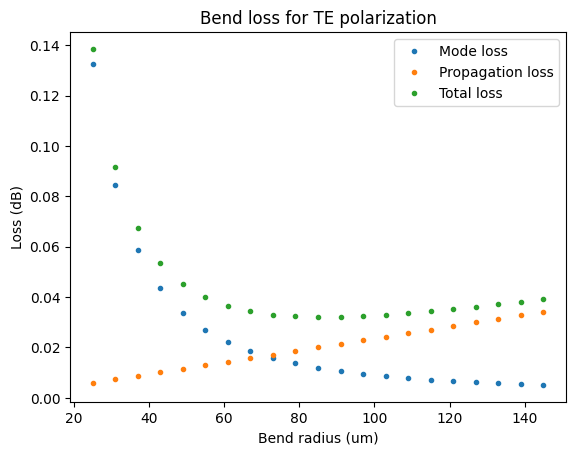

In [ ]:
dB_cm = 1.5  # dB/cm Technology loss - 
length = 0.5 * np.pi * radii * 1e-6
propagation_loss = dB_cm * length * 1e2
propagation_loss


plt.title("Bend loss for TE polarization")
plt.plot(radii, -10 * np.log10(mismatch), ".", label="Mode loss")
plt.plot(radii, propagation_loss, ".", label="Propagation loss")
plt.plot(radii, propagation_loss-10 * np.log10(mismatch), ".", label="Total loss")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB)")
plt.legend()

## EXTRA

All the past simulations were done considering as core material de Silicon Nitride (SiNx) and Silicon Dioxide (SiO2) as cladding material. Now, **simulate the Silicon-On-Insulator technology changing the core material to Silicon (Si)**. In this case, the dimensions will be 220 nm heigth and 500 nm width. 
1. Repeat the LO.1. wavelength behavior simulations, considering the updated materials and dimensions. 
2. Repeat the LO.2. width dependence analysis, now sweeping in a 300nm - 1um range. 
3. Find the safe radius for this technology. Consider sweeping the radius in a 5um to 30um range. 
4. **Compare the SiNx and SOI technologies** 

/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/d

08:56:50 -05 WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

2026-03-01 08:56:50.431 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_2b23fbc3e6bc4a22.npz.
2.4492791965235514


array([0.97697739, 0.06530927, 0.7213698 , 0.99281008])

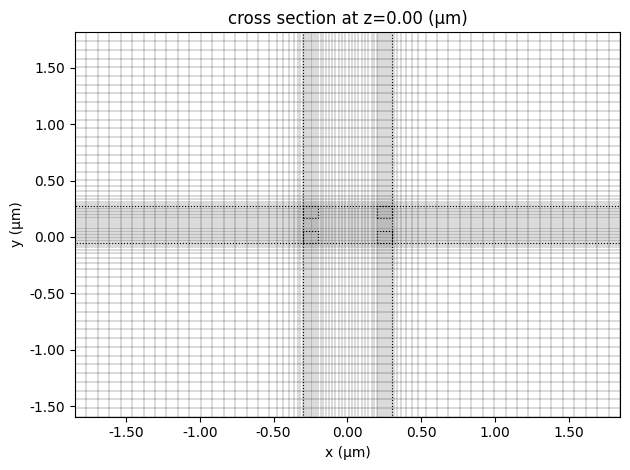

In [65]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=500 * nm, # Waveguide width
    core_thickness=220 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=4, # Targeted number of modes to find 
    max_grid_scaling=1.3, # Parameters of the grid 
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

#deep_waveguide.plot_index()
deep_waveguide.plot_grid() # para ver el mallado
print(deep_waveguide.n_eff[0].real) # calcular el indice

deep_waveguide.fraction_te

# Student continue your code here ...

In [69]:
n_eff_matrix=[]
grid_res=[]
for i in range(10,110,10):
    deep_waveguide = gt.modes.Waveguide(
         # Geometrical Parameters
        core_width=500 * nm, # Waveguide width
        core_thickness=220 * nm, # Waveguide height 
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        # Materials
        core_material='si', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=1550 * nm, # Wavelength to simulate
        num_modes=4, # Targeted number of modes to find 
        max_grid_scaling=1.3, # Parameters of the grid 
        grid_resolution=i, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )
    n_eff_matrix.append(deep_waveguide.n_eff[0].real)
    grid_res.append(i)

print (n_eff_matrix)

/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/d

08:58:48 -05 WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

2026-03-01 08:58:48.730 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_653ad81886b024c0.npz.
2026-03-01 08:58:48.746 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2b23fbc3e6bc4a22.npz.


/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/d

08:58:58 -05 WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

...

09:03:51 -05 WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

2026-03-01 09:03:51.801 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_887655545a638fce.npz.


/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/d

09:06:19 -05 WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

2026-03-01 09:06:19.972 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_ef1aa707e28a9210.npz.
[np.float64(2.5751171499687504), np.float64(2.4492791965235514), np.float64(2.458214372173532), np.float64(2.447222655696504), np.float64(2.447162498612837), np.float64(2.4471321975934694), np.float64(2.447102960937226), np.float64(2.4430795584285288), np.float64(2.4614843375501834), np.float64(2.4505232510359045)]


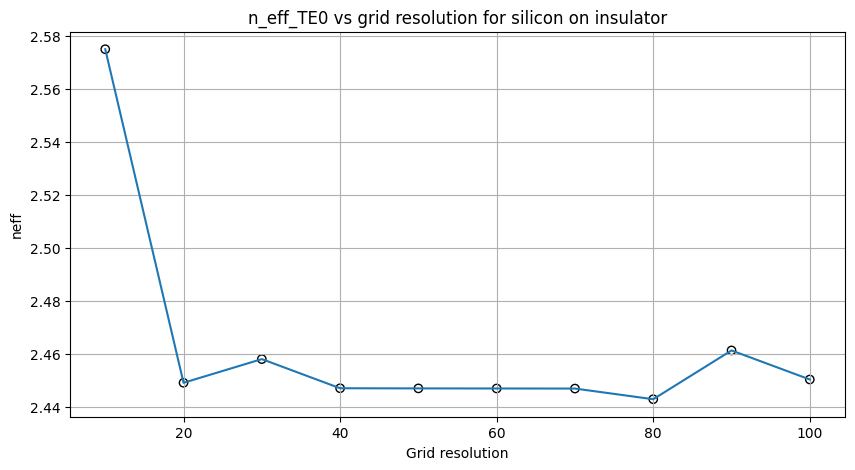

In [70]:
plt.figure(figsize=(10, 5))
plt.scatter(grid_res, n_eff_matrix,edgecolors='k',facecolors='none',label = '__nolegend__')
plt.plot(grid_res, n_eff_matrix)
plt.title(f"n_eff_TE0 vs grid resolution for silicon on insulator")
plt.xlabel("Grid resolution")
plt.ylabel("neff")
plt.grid()

In [74]:
#En este caso vemos que da bien para valores de 20 y de 40 a 70, asi que tomaremos 3 valores como en el caso anterior

n_eff_matrix_sca20=[]
grid_scaling=[]
for i in range(2,7,1):
    deep_waveguide = gt.modes.Waveguide(

        # Geometrical Parameters
        core_width=500 * nm, # Waveguide width
        core_thickness=220 * nm, # Waveguide height 
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        # Materials
        core_material='si', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=1550 * nm, # Wavelength to simulate
        num_modes=4, # Targeted number of modes to find 
        max_grid_scaling=1+i/10, # Parameters of the grid 
        grid_resolution=20, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )
    n_eff_matrix_sca20.append(deep_waveguide.n_eff[0].real)
    grid_scaling.append(1+i/10)


print(grid_scaling)

# para 40

n_eff_matrix_sca40=[]
for i in range(2,7,1):
    deep_waveguide = gt.modes.Waveguide(

        # Geometrical Parameters
        core_width=500 * nm, # Waveguide width
        core_thickness=220 * nm, # Waveguide height 
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        # Materials
        core_material='si', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=1550 * nm, # Wavelength to simulate
        num_modes=4, # Targeted number of modes to find 
        max_grid_scaling=1+i/10, # Parameters of the grid 
        grid_resolution=40, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )
    n_eff_matrix_sca40.append(deep_waveguide.n_eff[0].real)
    

#para 50

n_eff_matrix_sca50=[]
for i in range(2,7,1):
    deep_waveguide = gt.modes.Waveguide(

        # Geometrical Parameters
        core_width=500 * nm, # Waveguide width
        core_thickness=220 * nm, # Waveguide height 
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        # Materials
        core_material='si', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=1550 * nm, # Wavelength to simulate
        num_modes=4, # Targeted number of modes to find 
        max_grid_scaling=1+i/10, # Parameters of the grid 
        grid_resolution=50, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )
    n_eff_matrix_sca50.append(deep_waveguide.n_eff[0].real)
    


2026-03-01 09:19:33.861 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_223d93916735b32f.npz.
2026-03-01 09:19:33.876 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2b23fbc3e6bc4a22.npz.
2026-03-01 09:19:33.884 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_d2a12d2520042e19.npz.
[1.2, 1.3, 1.4, 1.5, 1.6]
2026-03-01 09:19:33.891 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_9b607c2ee0ef414d.npz.
2026-03-01 09:19:33.901 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_02d6f234e1cf89a5.npz.
2026-03-01 09:19:33.909 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e57b1482e9676d81.npz.
2026-03-01 09:19:33.919 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2df0b70c32556bb5.npz.
2026-03-01 09:19:33.936 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Wavegu

2026-03-01 09:19:33.955 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_b6d52bd5523d441b.npz.
2026-03-01 09:19:33.960 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_322d6affdb478ce7.npz.
2026-03-01 09:19:33.987 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_a44f40f4b17bc379.npz.
2026-03-01 09:19:33.997 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_911976577bac1427.npz.
2026-03-01 09:19:34.003 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cd190a93cf4fa7f1.npz.
2026-03-01 09:19:34.023 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2e7d1521ebf07a15.npz.
2026-03-01 09:19:34.029 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f3919e6a613c1494.npz.


[1.2, 1.3, 1.4, 1.5, 1.6]


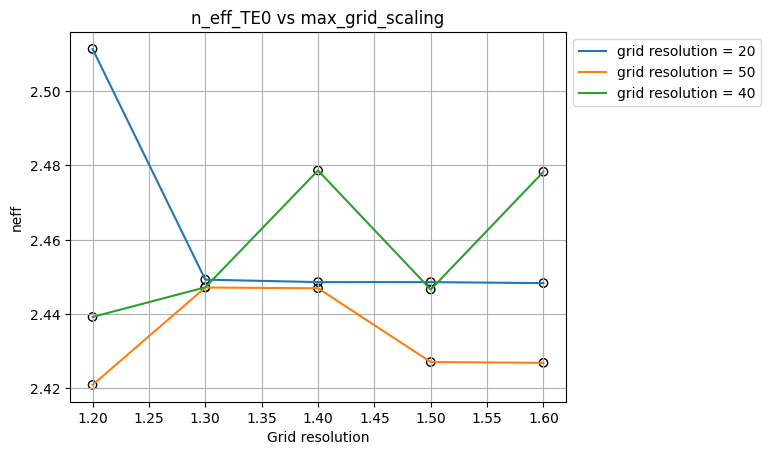

In [75]:
print(grid_scaling)

plt.scatter(grid_scaling, n_eff_matrix_sca20,edgecolors='k',facecolors='none')
plt.plot(grid_scaling, n_eff_matrix_sca20,label = 'grid resolution = 20')
plt.scatter(grid_scaling, n_eff_matrix_sca50,edgecolors='k',facecolors='none')
plt.plot(grid_scaling,n_eff_matrix_sca50,label = 'grid resolution = 50')
plt.scatter(grid_scaling, n_eff_matrix_sca40,edgecolors='k',facecolors='none')
plt.plot(grid_scaling,n_eff_matrix_sca40,label = 'grid resolution = 40')
plt.title(f"n_eff_TE0 vs max_grid_scaling")
plt.xlabel("Grid resolution")
plt.ylabel("neff")
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid()

  0%|          | 0/7 [00:00<?, ?it/s]

/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/d

09:28:12 -05 WARNING: Mode field at frequency index 0, mode index 2 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

2026-03-01 09:28:12.990 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_9fd1473f015a7c34.npz.


...

2026-03-01 09:28:25.401 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_30e7616b32a9db1c.npz.


/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/d

2026-03-01 09:28:27.815 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_8ab8fd47b3bf504b.npz.


  0%|          | 0/7 [00:00<?, ?it/s]

2026-03-01 09:28:27.859 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_9fd1473f015a7c34.npz.
2026-03-01 09:28:27.868 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_51e4d7b11e7712b7.npz.
2026-03-01 09:28:27.872 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2b23fbc3e6bc4a22.npz.
2026-03-01 09:28:27.880 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_b975db0abae852bd.npz.
2026-03-01 09:28:27.885 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_4723c77520ee8c07.npz.
2026-03-01 09:28:27.898 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_30e7616b32a9db1c.npz.
2026-03-01 09:28:27.904 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_8ab8fd47b3bf504b.npz.
0
[0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
<xarray.DataArray 'n_eff' (core_width: 7)> Size: 56B
array([1.79724386, 2.23418707, 2.4

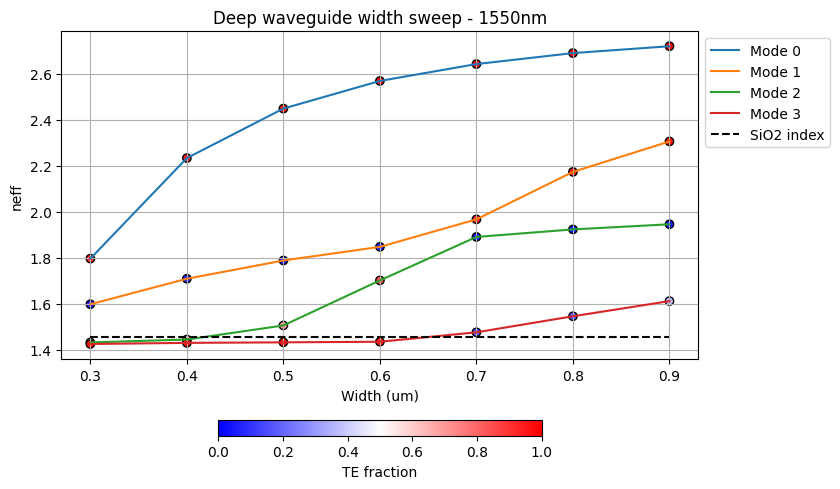

In [77]:
#LO.2. sweeping in a 300nm - 1um range. 

wavelength = 1.55 # Student code here

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    # Geometrical Parameters
    core_width=500 * nm, # Waveguide width
    core_thickness=220 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='si', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.3,
    grid_resolution=20, 
)


w = [] # Student code here Aqui debe ser un vector

for i in range (3,10,1):
    w.append(i/10)

sweep_neff = gt.modes.sweep_n_eff(deep_waveguide, 
                             core_width=w)

sweep_tefraction = gt.modes.sweep_fraction_te(deep_waveguide,
                                              core_width=w)

plt.figure(figsize=(10, 5))
for k in range(sweep_neff.shape[1]):
    plt.scatter(w, sweep_neff[:,k].real,edgecolors='k',c=sweep_tefraction.sel(mode_index=k),vmin=0, vmax=1,label = '__nolegend__',cmap='bwr')
    plt.plot(w, sweep_neff[:,k].real,label=f'Mode {k}')
    print(k)
    print(w)
    print(sweep_neff[:,k].real)
    

plt.title("Deep waveguide width sweep - 1550nm")
plt.xlabel("Width (um)")
plt.ylabel("neff")
plt.grid()
plt.hlines(np.mean(box_index), xmin=np.min(w), xmax=np.max(w), colors='k', linestyles='dashed',label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.colorbar(orientation='horizontal',fraction=0.04).set_label("TE fraction")


#rojo TE y azul TM

  0%|          | 0/13 [00:00<?, ?it/s]

/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/au/pic-upv-lab1-Copy1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/d

[0.99716677 0.99856376 0.9991336  0.99942071 0.99958565 0.99968912
 0.99975809 0.99980632 0.9998415  0.9998679  0.99988827 0.99990423
 0.99991694]


Text(0, 0.5, 'Mismatch (dB)')

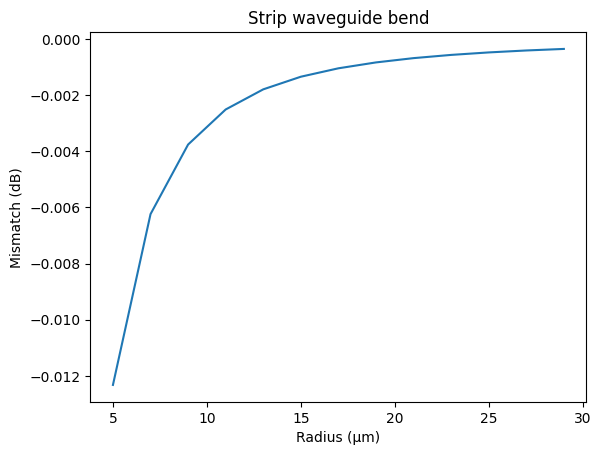

In [86]:
#Find the safe radius for this technology. Consider sweeping the radius in a 5um to 30um range. 

bend_1550 = gt.modes.Waveguide(
    wavelength=1550 * nm,
    slab_thickness=0.0,
    core_material='si',
    clad_material='sio2',
    core_width=500 * nm, # Waveguide width
    core_thickness=220 * nm, # Waveguide height 
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30, 
    bend_radius=25, # Bend radius
)


radii2 = np.arange(5, 30,2)

mismatch = gt.modes.sweep_bend_mismatch(bend_1550, radii2)
print(mismatch)

plt.plot(radii2, 10 * np.log10(mismatch))
plt.title("Strip waveguide bend")
plt.xlabel("Radius (μm)")
plt.ylabel("Mismatch (dB)")



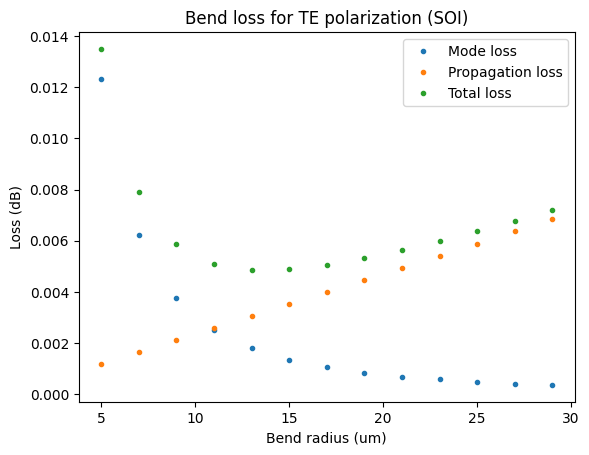

In [88]:
dB_cm = 1.5  # dB/cm Technology loss - 
length = 0.5 * np.pi * radii2 * 1e-6
propagation_loss = dB_cm * length * 1e2
propagation_loss


plt.title("Bend loss for TE polarization (SOI)")
plt.plot(radii2, -10 * np.log10(mismatch), ".", label="Mode loss")
plt.plot(radii2, propagation_loss, ".", label="Propagation loss")
plt.plot(radii2, propagation_loss-10 * np.log10(mismatch), ".", label="Total loss")
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB)")
plt.legend()

## Grading

LO.1. 2 Point <br> 
LO.2. 1 Points <br> 
LO.3. 3 Point <br> 
LO.4. 1 Points <br> 
**Total 7 Points** <br>
Extra (Up to) 3 Points
